In [24]:
# limit the thread used by numpy 
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"  

import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# import matplotlib
# matplotlib.rcParams['text.usetex'] = True
# matplotlib.rcParams['font.family'] = 'serif'

from Triangle.Constants import *
from Triangle.Orbit import * 
from Triangle.Noise import *
from Triangle.FFTTools import *
from Triangle.Data import * 
from Triangle.Cosmology import * 

from Triangle_BBH.Waveform import * 
from Triangle_BBH.Response import *
from Triangle_BBH.Utils import *
from Triangle_BBH.Fisher import *

np.random.seed(114514)

## Mission settings 

In [25]:
MISSION = "Taiji"
if MISSION == "Taiji": 
    nominal_arm = 3e9 
    acc_noise_budget = 3e-15 
    oms_noise_budget = 8e-12 
    orbit_dir = "../../Triangle-Simulator/OrbitData/MicroSateOrbitEclipticTCB"
    orbit_dt = DAY 
elif MISSION == "LISA": 
    pass 

## Data settings 

In [26]:
Tobs = 15. * DAY # data length in s 
t_start = 0. * DAY # start time in s
t_end = t_start + Tobs # end time in s 
dt = 20. # time cadance in s 
data_frequencies_full = np.fft.rfftfreq(n=int(Tobs/dt), d=dt) # frequecies where waveform will be calculated 
Tobs = int(Tobs/dt) * dt 
delta_f = 1. / Tobs

# mask the "null" frequencies, which may cause singularity in the calculation of likelihood 
mask = np.ones_like(data_frequencies_full, dtype=bool)
for i in range(1, 50): 
    mask_idx = np.where(np.abs(data_frequencies_full - i*C/4./nominal_arm)<i*3e-4)[0] # the 0.3mHz window is an empirical value
    mask[mask_idx] = False 

# remove the frequencies below sensitive band 
mask_idx = np.where(data_frequencies_full < 1e-5)[0]
mask[mask_idx] = False 

data_frequencies = data_frequencies_full[mask]

data_frequencies.shape, data_frequencies_full.shape 

((31976,), (32401,))

## Model settings 

### Orbit model 

In [27]:
orbit = Orbit(
    OrbitDir=orbit_dir, 
    dt=orbit_dt, 
)

### Waveform model 

In [28]:
WFG = WaveformGeneratorFRef(
    mode="primary", # "primary" for 22 mode only 
)

### TDI Response model and settings 

In [29]:
FDTDI = FDTDIResponseGeneratorFRef(
    orbit_class=orbit, 
    waveform_generator=WFG, 
)

response_kwargs_interp = dict(
    fmin=data_frequencies[-1], # used to calculate freq grid
    fmax=data_frequencies[0], # used to calculate freq grid
    fref=1e-3, # used to set reference point 
    Nfreqs=1024, # used to calculate freq grid
    modes=[(2, 2)], 
    tmin=t_start/DAY, # minimum time of orbit in day 
    tmax=t_end/DAY, # maximum time of orbit in day
    tref_at_constellation=True, # whether tref is the defined at detector center (True) or SSB (False)
    TDIGeneration='2nd',
    optimal_combination=True, # True for AET, False for XYZ 
)

response_kwargs_direct = dict(
    fref=1e-3, # used to set reference point 
    modes=[(2, 2)], 
    tmin=t_start/DAY, # minimum time of orbit in day 
    tmax=t_end/DAY, # maximum time of orbit in day
    tref_at_constellation=True, # whether tref is the defined at detector center (True) or SSB (False)
    TDIGeneration='2nd',
    optimal_combination=True, # True for AET, False for XYZ 
    interpolation_method=None, 
)

channel_names = ["A", "E", "T"]
channel_colors = [RED, BLUE, ORANGE]

### Noise model 

In [30]:
# set detector noise model 
PSDfunc = TDIPSDs(
    sacc=acc_noise_budget, 
    sro=oms_noise_budget, 
    L=nominal_arm, 
) 

# average over observation times to get noise CSD 
psd_a = np.zeros_like(data_frequencies)
psd_e = np.zeros_like(data_frequencies)
psd_t = np.zeros_like(data_frequencies)
noise_times = np.linspace(t_start, t_end, int(Tobs/DAY))
for itime in tqdm(range(len(noise_times))):
    arms = dict()
    for key in MOSA_labels: 
        arms[key] = orbit.LTTfunctions()[key](noise_times[itime])
    psd_a += PSDfunc.PSD_A2_unequal(data_frequencies, arms)
    psd_e += PSDfunc.PSD_E2_unequal(data_frequencies, arms)
    psd_t += PSDfunc.PSD_T2_unequal(data_frequencies, arms)
psd_a *= 1. / len(noise_times)
psd_e *= 1. / len(noise_times)
psd_t *= 1. / len(noise_times)
psd_channels = np.array([psd_a, psd_e, psd_t])

# noise-othorgonal approximation
csd_ae = np.zeros_like(psd_a)
csd_et = np.zeros_like(psd_a)
csd_ta = np.zeros_like(psd_a)

# noise orthogonal assumption 
covmatrix = np.array([
    [psd_a, csd_ae, np.conjugate(csd_ta)], 
    [np.conjugate(csd_ae), psd_e, csd_et], 
    [csd_ta, np.conjugate(csd_et), psd_t],
]) / 4. / delta_f # (3, 3, Nf)

inv_covmatrix = np.linalg.inv(np.transpose(covmatrix, axes=(2, 0, 1))) # (Nf, 3, 3)
# set the 3-3 element to 0 so that T channel will not be used in likelihood calculation
inv_covmatrix[:, 2, 2] *= 0. 

100%|██████████| 15/15 [00:00<00:00, 31.69it/s]


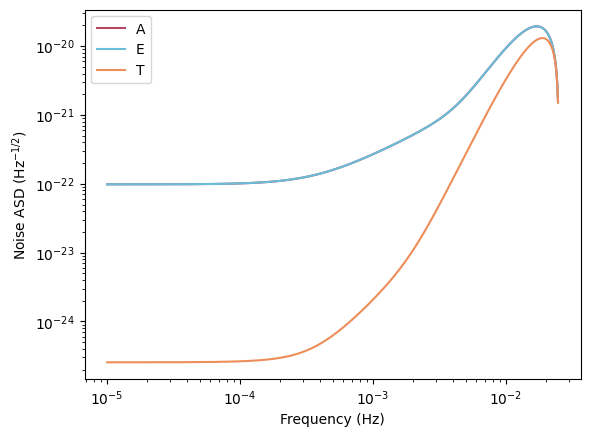

In [31]:
for i in range(3): 
    plt.loglog(data_frequencies, np.sqrt(psd_channels[i]), label=channel_names[i], color=channel_colors[i])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Noise ASD "+r'$({\rm Hz^{-1/2}})$')
plt.legend(loc="upper left")

## Data Generation 

In [32]:
mbhb_parameters = {
    'chirp_mass': 1527693.2821010326, # solar mass, redshifted 
    'mass_ratio': 0.6060083963754411,
    'spin_1z': 0.4, 
    'spin_2z': -0.6,
    'reference_time': 10.927959071370836, # day 
    'reference_phase': 2.1563629722527997, # rad 
    'luminosity_distance': 22016.264842325963, # mpc 
    'inclination': 1.9340646499796517, # rad 
    'longitude': 3.279277442759269, # rad, ecliptic 
    'latitude': 0.9176152704924524, # rad, ecliptic 
    'psi': 1.988850127130235 # rad 
    }

data_channels = FDTDI.Response(
    mbhb_parameters, 
    data_frequencies, 
    **response_kwargs_direct, 
)

snr = FrequencyDomainCovarianceSNR(data_channels, inv_covmatrix)
print("signal-to-noise ratio is", snr)

signal-to-noise ratio is 2392.5825236569995


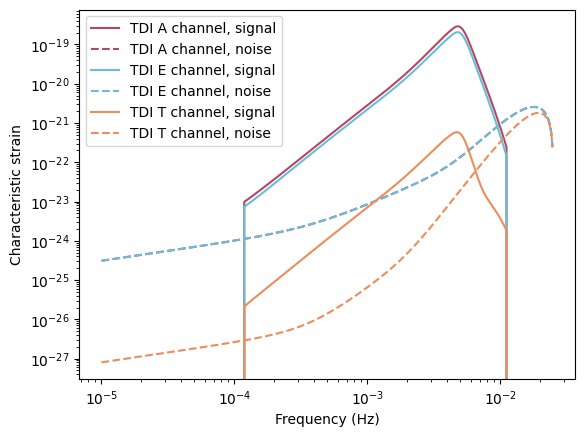

In [33]:
for i in range(3): 
    plt.loglog(data_frequencies, np.abs(data_channels[i]) * 2. * data_frequencies, label="TDI "+channel_names[i]+" channel, signal", color=channel_colors[i])
    plt.loglog(data_frequencies, np.sqrt(psd_channels[i] * data_frequencies), label="TDI "+channel_names[i]+" channel, noise", color=channel_colors[i], linestyle="--")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Characteristic strain")
plt.legend(loc="upper left")

## Fisher analysis 

In [34]:
def fisher_waveform_wrapper(param_dict, frequencies):
    res = FDTDI.Response(
        param_dict, 
        frequencies,  
        **response_kwargs_interp, 
    )
    return res

# set initial steps for FIM calculation 
analyze_param_step_dict = {
    'chirp_mass': 10.,
    'mass_ratio': 0.01,
    'spin_1z': 0.01,
    'spin_2z': 0.01,
    'reference_time': 0.01,
    'reference_phase': 0.01,
    'luminosity_distance': 100.,
    'inclination': 0.01,
    'longitude': 0.01,
    'latitude': 0.01,
    'psi': 0.01
    }
for k, v in analyze_param_step_dict.items():
    analyze_param_step_dict[k] = -v 

FIM = MultiChannelFisher(
    waveform_generator=fisher_waveform_wrapper, 
    param_dict=mbhb_parameters, 
    analyze_param_step_dict=analyze_param_step_dict, 
    frequency=data_frequencies, 
    inverse_covariance=inv_covmatrix,
    verbose=0
)
FIM.auto_test_step()
FIM.calculate_Fisher()
FIM.calculate_errors() 

FIM.param_errors

{'chirp_mass': 325.08646738358806,
 'mass_ratio': 0.004111140037313483,
 'spin_1z': 0.016068386797107797,
 'spin_2z': 0.031901241916633204,
 'reference_time': 1.1541939295342105e-05,
 'reference_phase': 0.028745921235427057,
 'luminosity_distance': 1286.664231075452,
 'inclination': 0.016528941662170685,
 'longitude': 0.038799689657363745,
 'latitude': 0.021075399086470752,
 'psi': 0.021399744072163884}

## Parameter estimation with bilby 

In [35]:
import bilby 

### prior

In [36]:
# set prior to be 10 sigma around the truths 
priors = bilby.core.prior.PriorDict()
priors["chirp_mass"] = bilby.prior.Uniform(minimum=mbhb_parameters["chirp_mass"]-10.*FIM.param_errors["chirp_mass"], maximum=mbhb_parameters["chirp_mass"]+10.*FIM.param_errors["chirp_mass"], name='chirp_mass', latex_label='$\mathcal{M}_c$')
priors["mass_ratio"] = bilby.prior.Uniform(minimum=max(0.1, mbhb_parameters["mass_ratio"]-10.*FIM.param_errors["mass_ratio"]), maximum=min(0.99, mbhb_parameters["mass_ratio"]+10.*FIM.param_errors["mass_ratio"]), name="mass_ratio", latex_label='$q$')
priors["spin_1z"] = bilby.prior.Uniform(minimum=-0.9, maximum=0.9, name="spin_1z", latex_label='$\chi_{z1}$')
priors["spin_2z"] = bilby.prior.Uniform(minimum=-0.9, maximum=0.9, name="spin_1z", latex_label='$\chi_{z2}$')
priors["reference_time"] = bilby.prior.Uniform(minimum=mbhb_parameters["reference_time"]-10.*FIM.param_errors["reference_time"], maximum=mbhb_parameters["reference_time"]+10.*FIM.param_errors["reference_time"], name="reference_time", latex_label='$t_\mathrm{ref}$') 
priors["reference_phase"] = bilby.prior.Uniform(minimum=0., maximum=TWOPI, name="reference_phase", latex_label='$\\varphi_\mathrm{ref}$', boundary="periodic")
priors["luminosity_distance"] = bilby.prior.Uniform(minimum=max(6e3, mbhb_parameters["luminosity_distance"]-10.*FIM.param_errors["luminosity_distance"]), maximum=min(1e5, mbhb_parameters["luminosity_distance"]+10.*FIM.param_errors["luminosity_distance"]), name="luminosity_distance", latex_label='$d_L$')
priors["inclination"] = bilby.prior.Sine(minimum=0., maximum=PI, name="inclination", latex_label='$\iota$')
priors["longitude"] = bilby.prior.Uniform(minimum=0., maximum=TWOPI, name="longitude", latex_label='$\lambda$', boundary="periodic")
priors["latitude"] = bilby.prior.Cosine(minimum=-PI/2., maximum=PI/2., name="latitude", latex_label='$\\beta$')
priors["psi"] = bilby.prior.Uniform(minimum=0., maximum=PI, name="psi", latex_label='$\psi$', boundary="periodic")

estimate_parameters = ["chirp_mass", "mass_ratio"]
for param_name in priors.keys(): 
    if param_name in estimate_parameters: 
        pass 
    else: 
        priors[param_name] = mbhb_parameters[param_name]
        
priors

{'chirp_mass': Uniform(minimum=1524442.4174271966, maximum=1530944.1467748685, name='chirp_mass', latex_label='$\\mathcal{M}_c$', unit=None, boundary=None),
 'mass_ratio': Uniform(minimum=0.5648969960023063, maximum=0.647119796748576, name='mass_ratio', latex_label='$q$', unit=None, boundary=None),
 'spin_1z': 0.4,
 'spin_2z': -0.6,
 'reference_time': 10.927959071370836,
 'reference_phase': 2.1563629722527997,
 'luminosity_distance': 22016.264842325963,
 'inclination': 1.9340646499796517,
 'longitude': 3.279277442759269,
 'latitude': 0.9176152704924524,
 'psi': 1.988850127130235}

### Likelihood
$${\rm ln} \mathcal{L}(\theta) = -\frac{1}{2}(d - h(\theta) | d - h(\theta))$$

In [38]:
Like_interp = Likelihood(
    response_generator=FDTDI, 
    frequency=data_frequencies, 
    data=data_channels, 
    invserse_covariance_matrix=inv_covmatrix, 
    response_parameters=response_kwargs_interp, 
    use_gpu=False, 
    verbose=0
)

Like_direct = Likelihood(
    response_generator=FDTDI, 
    frequency=data_frequencies, 
    data=data_channels, 
    invserse_covariance_matrix=inv_covmatrix, 
    response_parameters=response_kwargs_direct, 
    use_gpu=False, 
    verbose=0
)

fiducial_parameters = ParamDict2ParamArr(mbhb_parameters)
Like_direct.prepare_het_log_like(base_parameters=fiducial_parameters)

KeyError: 'coalescence_time'

In [13]:
class bilby_likelihood_wrapper(bilby.Likelihood):
    def __init__(self):
        super().__init__(
            parameters={
                'chirp_mass': None,
                'mass_ratio': None,
                'spin_1z': None,
                'spin_2z': None,
                'reference_time': None,
                'reference_phase': None,
                'luminosity_distance': None,
                'inclination': None,
                'longitude': None,
                'latitude': None,
                'psi': None
            }
        )

    def log_likelihood(self):
        temp_channels = FDTDI.Response(
            self.parameters, 
            data_frequencies, 
            **response_kwargs, 
        ) # (3, Nf)
        return -0.5 * FrequencyDomainCovarianceSNR(data_channels=temp_channels-data_channels, inv_cov=inv_covmatrix) ** 2 

In [14]:
BLike = bilby_likelihood_wrapper()

import multiprocessing
ncpu = multiprocessing.cpu_count()
print("number of cpus =", ncpu)

result = bilby.run_sampler(
    likelihood=BLike, 
    priors=priors,
    sampler="nessai", 
    nlive=2000,
    # walks=20,
    # nact=50,
    # maxmcmc=2000,
    stopping=0.1, 
    npool=ncpu, # use all cpus 
    injection_parameters=mbhb_parameters, 
    outdir="../../Samples",
    label="tribbh_example",
    plot=True,
    resume=False, 
    # resume=True, 
)

15:20 bilby INFO    : Running for label 'tribbh_example', output will be saved to '../../Samples'


number of cpus = 32


/home/ps/miniconda3/envs/tri_env/lib/python3.9/site-packages/bilby/core/utils/log.py:73: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  vdict[key] = str(getattr(sys.modules[key], "__version__", "N/A"))
15:20 bilby INFO    : Analysis priors:
15:20 bilby INFO    : chirp_mass=Uniform(minimum=1525663.2146944408, maximum=1529723.3495076243, name='chirp_mass', latex_label='$\\mathcal{M}_c$', unit=None, boundary=None)
15:20 bilby INFO    : mass_ratio=Uniform(minimum=0.5996954307676672, maximum=0.6123213619832151, name='mass_ratio', latex_label='$q$', unit=None, boundary=None)
15:20 bilby INFO    : reference_time=Uniform(minimum=10.927927566282643, maximum=10.92799057645903, name='reference_time', latex_label='$t_\\mathrm{ref}$', unit=None, boundary=None)
15:20 bilby INFO    : reference_phase=Uniform(minimum=0.0, maximum=6.283185307179586, name='reference_phase', late

09-23 15:20 nessai INFO    : Running Nessai version 0.14.0.post0
09-23 15:20 nessai INFO    : Starting multiprocessing pool with 32 processes


/home/ps/miniconda3/envs/tri_env/lib/python3.9/site-packages/nessai/utils/logging.py:133: FutureWarning: setup_logger is deprecated, use configure_logger instead
  warnings.warn(


...

13:29 bilby WARNING : Sampler is not initialized
13:29 bilby WARNING : Sampler is not initialized
13:29 bilby WARNING : Sampler is not initialized
13:29 bilby WARNING : Sampler is not initialized
13:29 bilby WARNING : Sampler is not initialized
13:29 bilby WARNING : Sampler is not initialized
13:29 bilby WARNING : Sampler is not initialized
13:29 bilby WARNING : Sampler is not initialized
13:29 bilby WARNING : Sampler is not initialized
13:29 bilby WARNING : Sampler is not initialized
13:29 bilby WARNING : Sampler is not initialized
13:29 bilby WARNING : Sampler is not initialized
13:29 bilby WARNING : Sampler is not initialized
13:29 bilby INFO    : Run interrupted by signal 2: checkpoint and exit on 130
13:29 bilby WARNING : Sampler is not initialized
13:29 bilby WARNING : Sampler is not initialized
13:29 bilby WARNING : Sampler is not initialized
13:29 bilby WARNING : Sampler is not initialized
13:29 bilby INFO    : Run interrupted by signal 2: checkpoint and exit on 130
13:29 bilby

09-26 13:29 nessai INFO    : Finished closing worker pool.
09-26 13:29 nessai INFO    : Checkpointing nested sampling


13:29 bilby INFO    : Run interrupted by signal 2: checkpoint and exit on 130


SystemExit: 130

/home/ps/miniconda3/envs/tdc/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3558: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
result.plot_corner(save=True)